### Dateset plots - setup

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"

print("Project root:", PROJECT_ROOT)
print("Data dir:", DATA_DIR)

Project root: /Users/mateuszwojtowicz/Developer/PK/MGR/kod_zrodlowy/eye-gesture-identification
Data dir: /Users/mateuszwojtowicz/Developer/PK/MGR/kod_zrodlowy/eye-gesture-identification/data


In [28]:
def quaternions_to_gaze_vectors(df):
    """
    Zamiana left/right eye local rotation na wspolny gaze vector
    """
    required_cols = [
        "LeftLocalRotX", "LeftLocalRotY", "LeftLocalRotZ", "LeftLocalRotW",
        "RightLocalRotX", "RightLocalRotY", "RightLocalRotZ", "RightLocalRotW",
    ]

    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    left_quat = df[["LeftLocalRotX", "LeftLocalRotY", "LeftLocalRotZ", "LeftLocalRotW"]].astype(float).to_numpy()
    right_quat = df[["RightLocalRotX", "RightLocalRotY", "RightLocalRotZ", "RightLocalRotW"]].astype(float).to_numpy()

    forward = np.array([0.0, 0.0, 1.0])

    left_vectors = Rotation.from_quat(left_quat).apply(forward)
    right_vectors = Rotation.from_quat(right_quat).apply(forward)

    gaze_vectors = left_vectors + right_vectors
    gaze_vectors = gaze_vectors / np.linalg.norm(gaze_vectors, axis=1, keepdims=True)

    return gaze_vectors


def add_gaze_speed(df):
    """
    Dodaje:
    - Time_s
    - gaze_angle_step_deg
    - gaze_speed_deg_s
    """
    out = df.copy()

    out["Time_s"] = (
        out["Time_ms"].astype(float) - float(out["Time_ms"].iloc[0])
    ) / 1000.0

    gaze_vectors = quaternions_to_gaze_vectors(out)

    angle_step = np.zeros(len(out), dtype=float)

    if len(out) > 1:
        dot = np.sum(gaze_vectors[1:] * gaze_vectors[:-1], axis=1)
        dot = np.clip(dot, -1.0, 1.0)
        angle_step[1:] = np.degrees(np.arccos(dot))

    dt = out["Time_s"].diff().to_numpy().copy()
    dt[dt <= 0] = np.nan

    speed = angle_step / dt
    speed = np.nan_to_num(speed, nan=0.0, posinf=0.0, neginf=0.0)

    out["gaze_angle_step_deg"] = angle_step
    out["gaze_speed_deg_s"] = speed

    return out

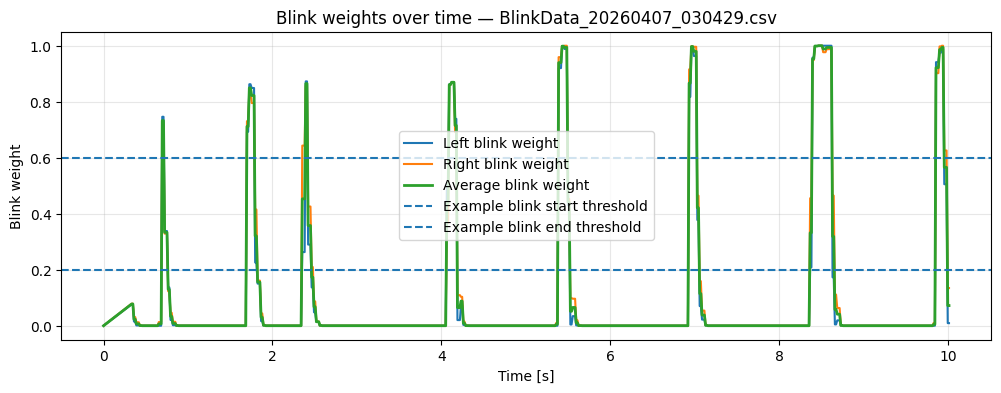

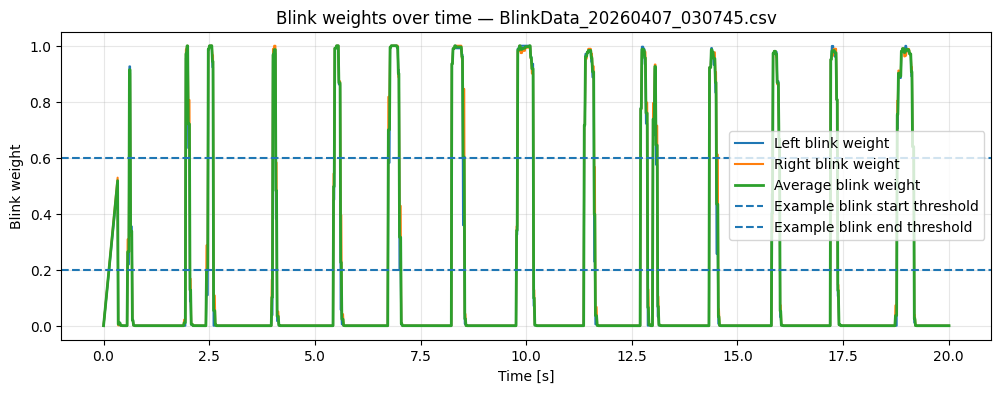

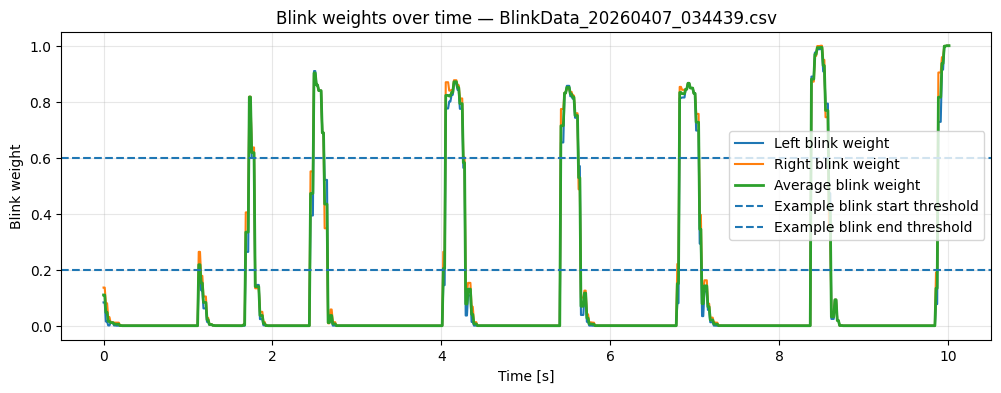

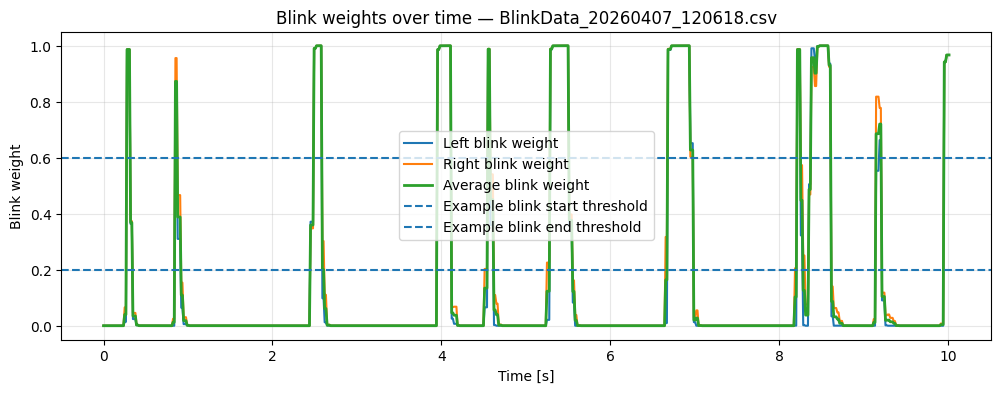

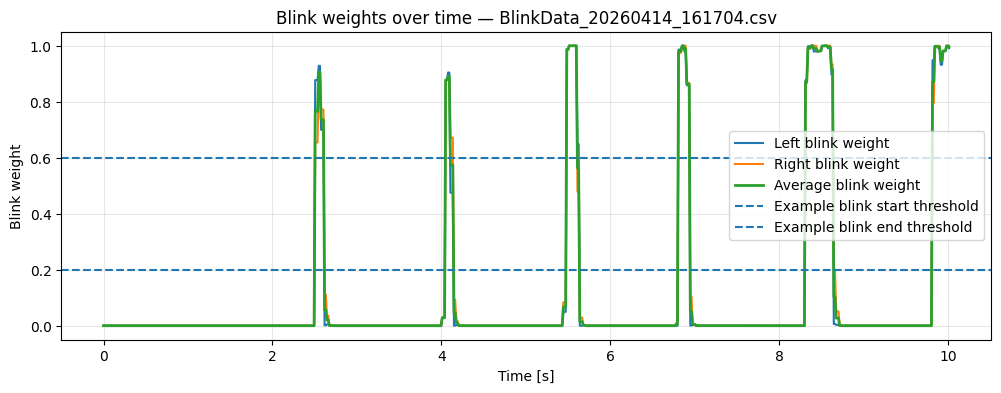

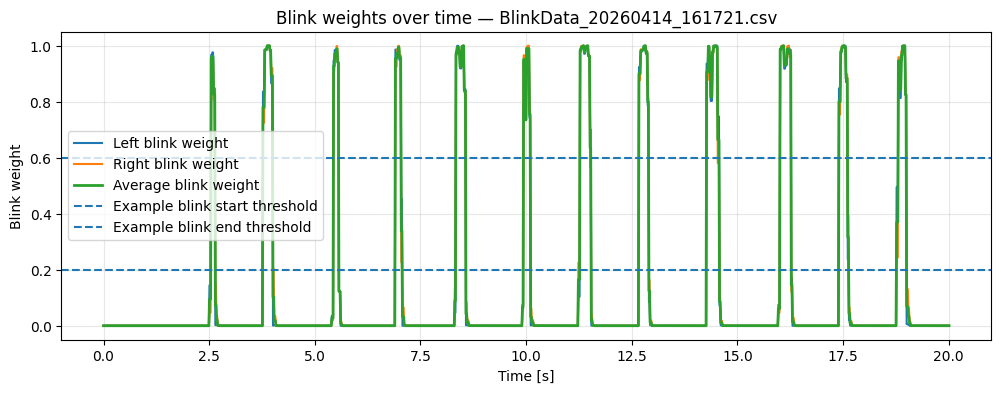

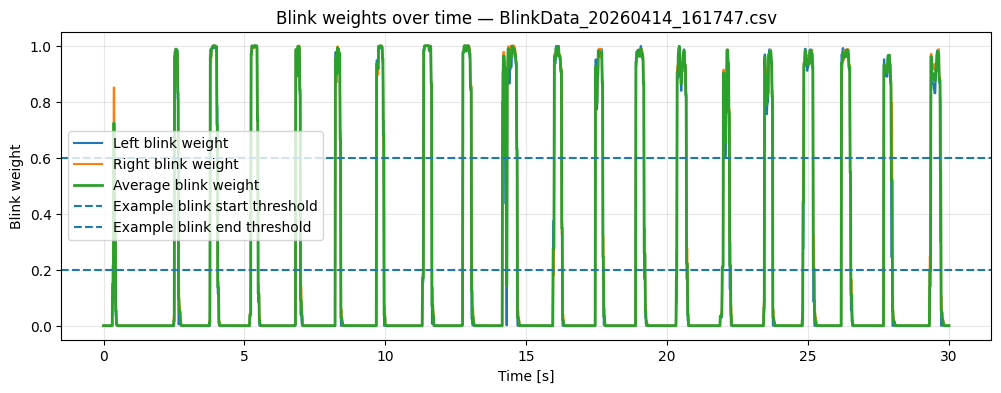

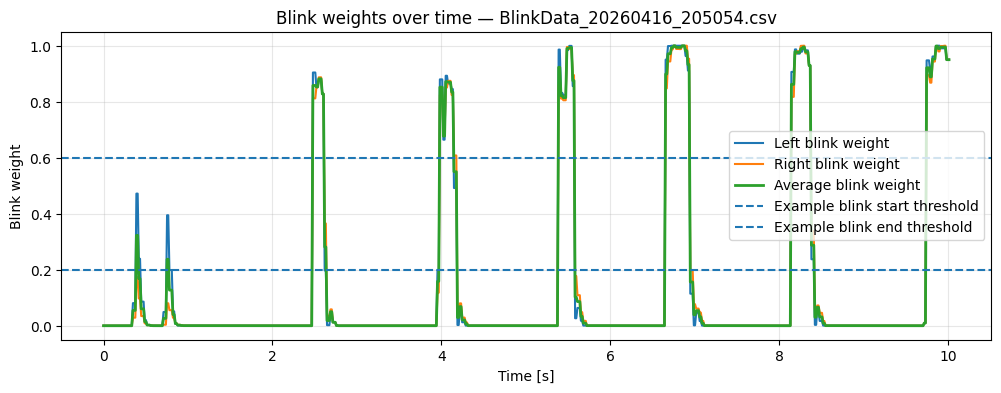

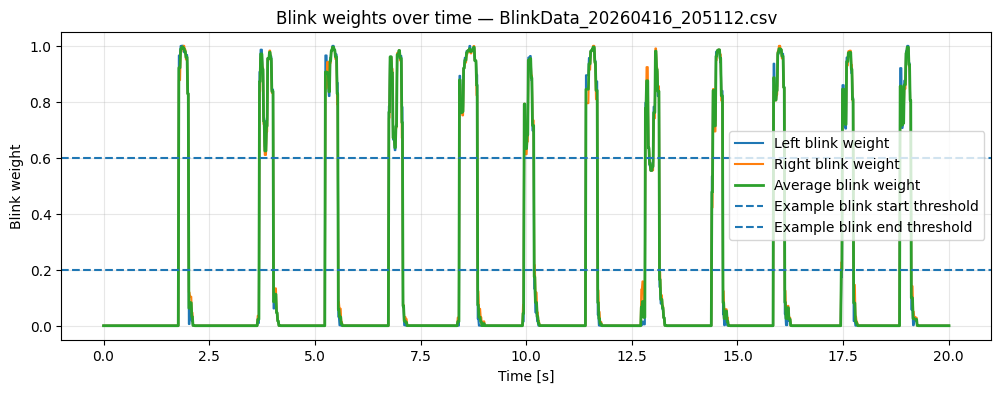

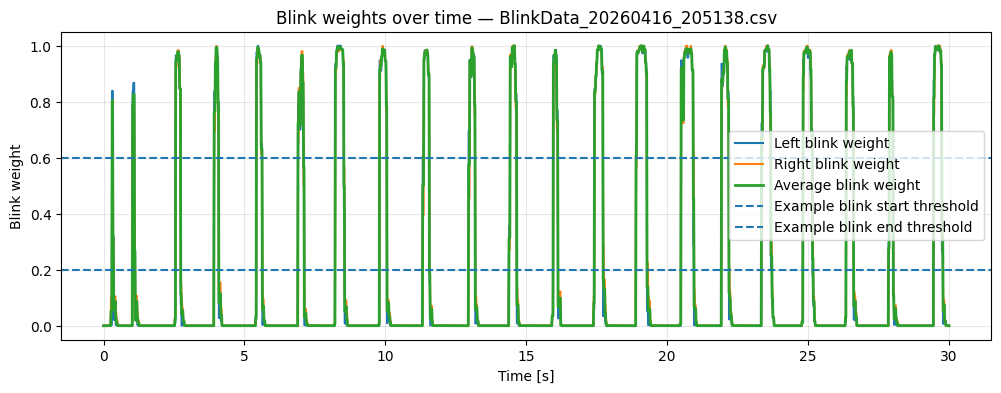

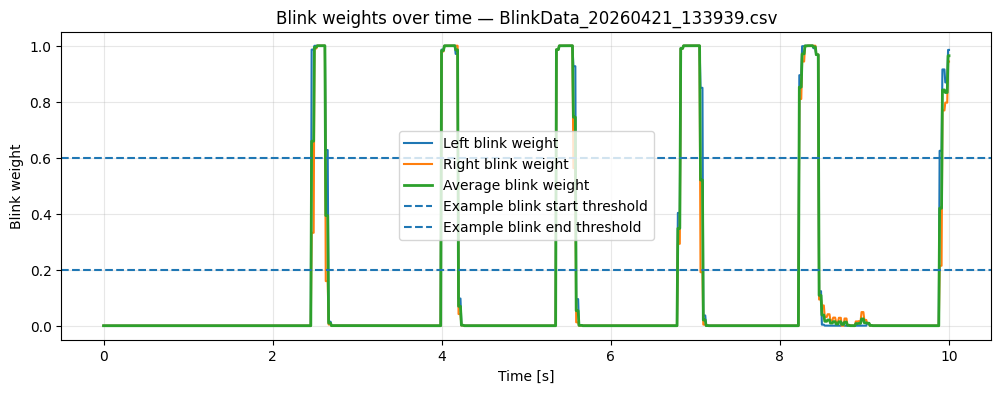

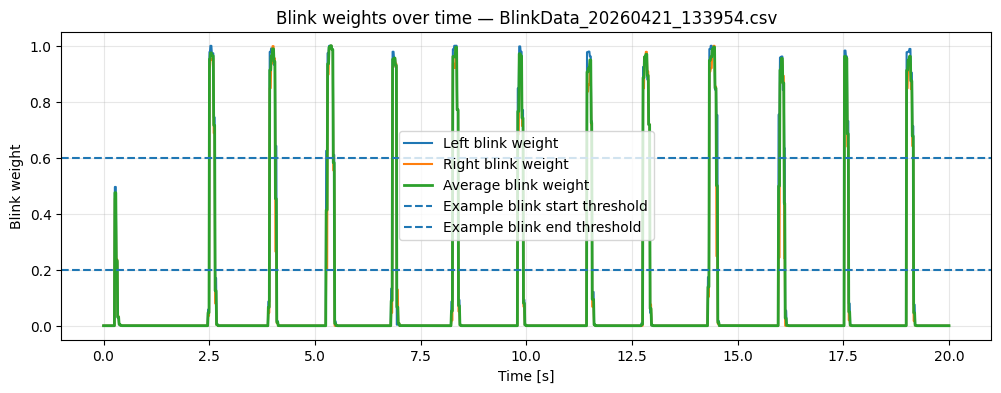

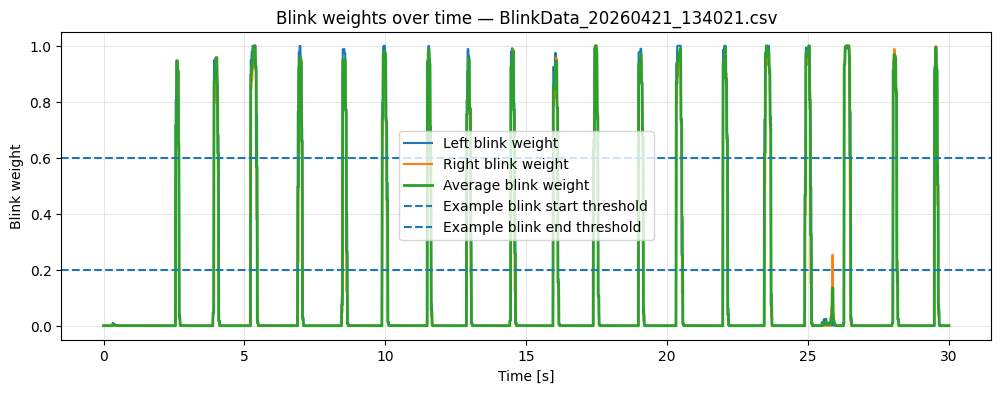

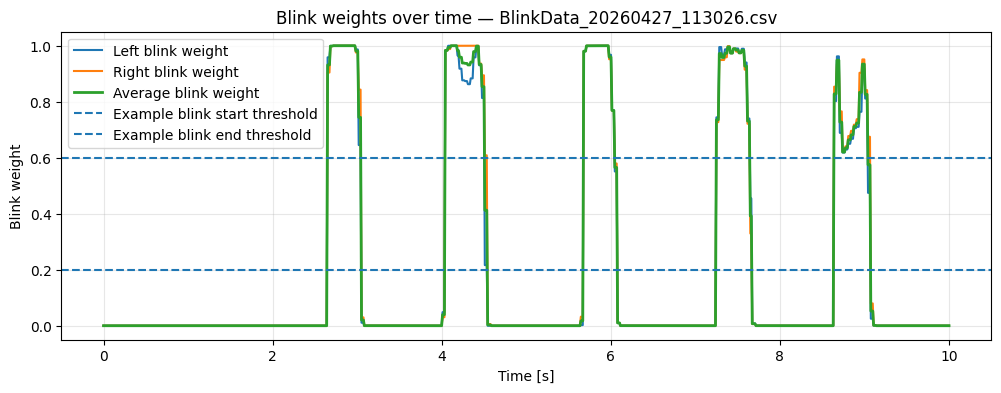

In [29]:
blink_files = sorted(DATA_DIR.glob("BlinkData*.csv"))

for file_path in blink_files:
    df = pd.read_csv(file_path)

    df["Time_s"] = (df["Time_ms"].astype(float) - float(df["Time_ms"].iloc[0])) / 1000.0
    df["BlinkAvg"] = (df["LeftBlinkWeight"].astype(float) + df["RightBlinkWeight"].astype(float)) / 2.0

    plt.figure(figsize=(12, 4))

    plt.plot(df["Time_s"], df["LeftBlinkWeight"], label="Left blink weight")
    plt.plot(df["Time_s"], df["RightBlinkWeight"], label="Right blink weight")
    plt.plot(df["Time_s"], df["BlinkAvg"], label="Average blink weight", linewidth=2)

    plt.axhline(0.60, linestyle="--", label="Example blink start threshold")
    plt.axhline(0.20, linestyle="--", label="Example blink end threshold")

    plt.title(f"Blink weights over time — {file_path.name}")
    plt.xlabel("Time [s]")
    plt.ylabel("Blink weight")
    plt.ylim(-0.05, 1.05)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

In [30]:
saccade_files = sorted(DATA_DIR.glob("SaccadeData*.csv"))

for file_path in saccade_files:
    df = pd.read_csv(file_path)
    df = add_gaze_speed(df)

    plt.figure(figsize=(12, 4))

    plt.plot(df["Time_s"], df["gaze_speed_deg_s"], label="Gaze speed")

    plt.axhline(80, linestyle="--", label="High speed reference: 80 deg/s")
    plt.axhline(120, linestyle="--", label="Saccade threshold reference: 120 deg/s")

    plt.title(f"Gaze speed over time — {file_path.name}")
    plt.xlabel("Time [s]")
    plt.ylabel("Gaze speed [deg/s]")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

ValueError: Missing columns: ['LeftLocalRotX', 'LeftLocalRotY', 'LeftLocalRotZ', 'LeftLocalRotW', 'RightLocalRotX', 'RightLocalRotY', 'RightLocalRotZ', 'RightLocalRotW']

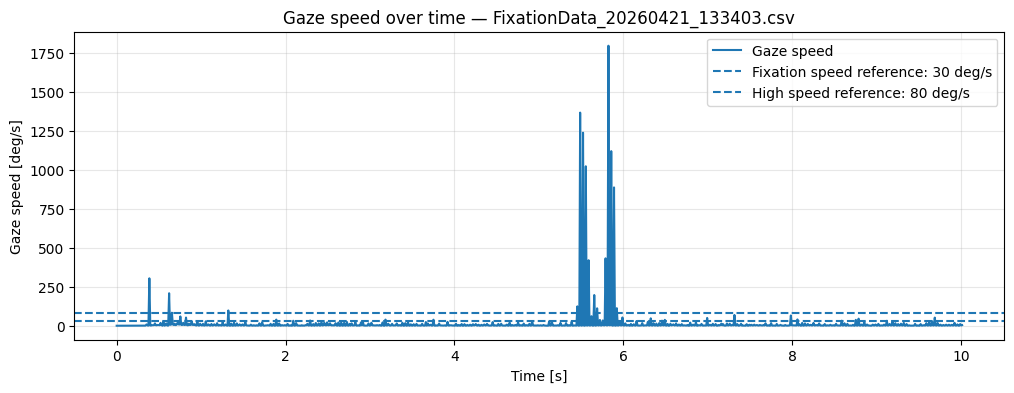

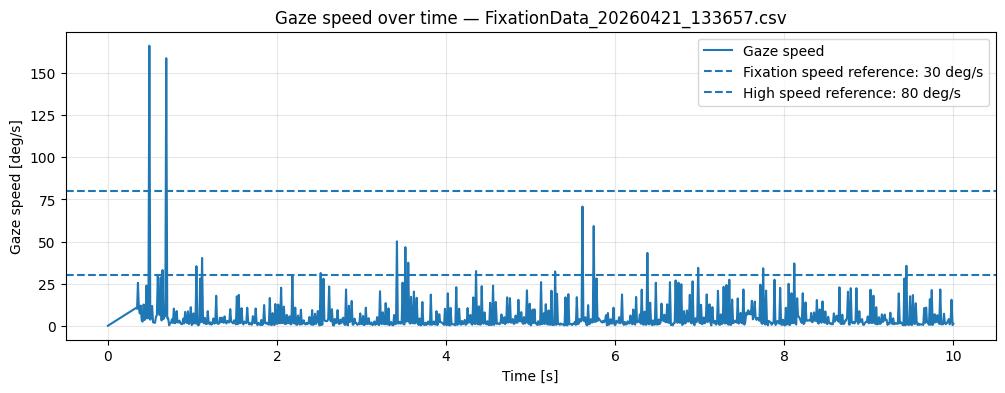

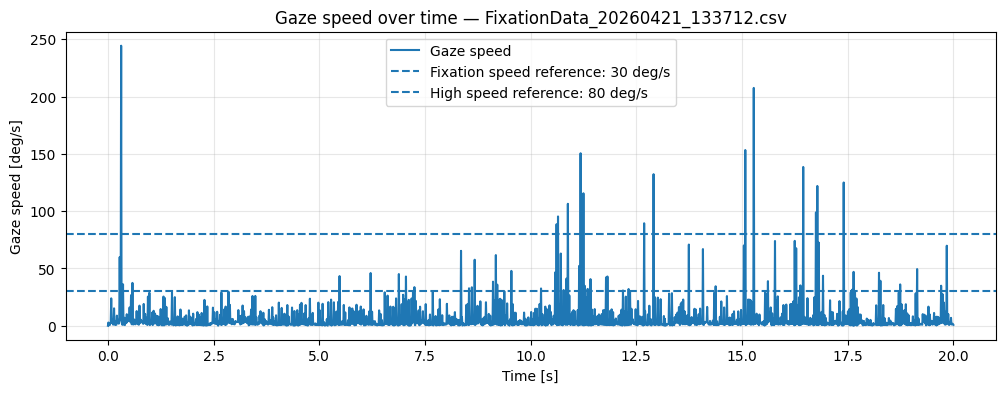

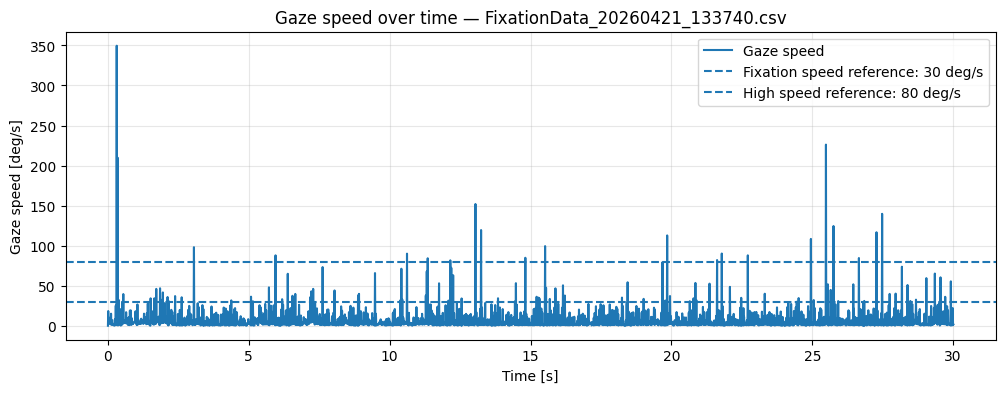

In [ ]:
fixation_files = sorted(DATA_DIR.glob("FixationData*.csv"))

for file_path in fixation_files:
    df = pd.read_csv(file_path)
    df = add_gaze_speed(df)

    plt.figure(figsize=(12, 4))

    plt.plot(df["Time_s"], df["gaze_speed_deg_s"], label="Gaze speed")

    plt.axhline(30, linestyle="--", label="Fixation speed reference: 30 deg/s")
    plt.axhline(80, linestyle="--", label="High speed reference: 80 deg/s")

    plt.title(f"Gaze speed over time — {file_path.name}")
    plt.xlabel("Time [s]")
    plt.ylabel("Gaze speed [deg/s]")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()